In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 51
==================================================
Week: 8 of 24
Day: 51 of 168
Date: Tuesday, December 17, 2024
Topic: BERT Fine-tuning & LSTM Comparison
Overall Progress: 30.4%

Week 8 Progress:
✅ Day 50: Transformer Architecture Study (COMPLETED)
🔄 Day 51: BERT Fine-tuning & LSTM Comparison (TODAY!)
⬜ Day 52: Job-Resume Matcher (Sentence-BERT)
⬜ Day 53: Job Matcher Features & Testing
⬜ Day 54: Text Summarizer (T5/BART)
⬜ Day 55: Fake News Detector (BERT)
⬜ Day 56: Integration Testing & Optimization

Progress: 14.3% (1/7 days)

==================================================
🎯 Week 8 Project: TextAI Studio - Transformers & Advanced NLP
- Week 7: LSTM Sentiment Analyzer ✅ (80.38% accuracy)
- Day 50: Transformer Architecture ✅
- Day 51: BERT Fine-tuning (Beat LSTM!)
- Days 52-56: Build 4 NLP tools

==================================================
🎯 Today's Learning Objectives:
1. Load IMDB dataset (same as Week 7 for direct comparison)
   - 50,000 movie reviews
   - Binary sentiment classification
   - Preprocessing for BERT format

2. Fine-tune BERT for sentiment analysis
   - Add classification head on BERT
   - Train with AdamW optimizer + warmup
   - Learning rate scheduling
   - Target: 90%+ accuracy (beat LSTM's 80.38%)

3. Comprehensive comparison: BERT vs LSTM
   - Accuracy and convergence speed
   - Error analysis: What does BERT catch that LSTM misses?
   - Attention visualization
   - Model size vs performance tradeoff

==================================================
📚 Today's Structure:
Part 1 (1.5h): Dataset Loading & Preprocessing
Part 2 (2.5h): BERT Fine-tuning & Training
Part 3 (1.5h): Evaluation & LSTM Comparison
Part 4 (1h): Analysis & Insights

==================================================
🎯 SUCCESS CRITERIA:
✅ Successfully load and preprocess IMDB dataset for BERT
✅ Fine-tune BERT with proper training loop
✅ Achieve 90%+ validation accuracy (beat LSTM's 80.38%)
✅ Complete comparison analysis with Week 7 LSTM
✅ Understand performance improvements from BERT

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================
import sys
print(f"Python executable: {sys.executable}")
print("\n⏱ Installing/upgrading libraries...\n")

!python -m pip install transformers datasets torch scikit-learn matplotlib seaborn pandas numpy tqdm --upgrade -q

print("\n✅ Libraries installed!")
print("\n" + "=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Hugging Face
import transformers
from transformers import (
    BertTokenizer, 
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset

# Sklearn
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Progress bar
from tqdm.auto import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"\n✅ PyTorch version: {torch.__version__}")
print(f"✅ Transformers version: {transformers.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("ℹ️  Running on CPU (training will be slower)")
    print("   Recommended: Use Google Colab with GPU for faster training")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create results directories
os.makedirs('results/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("\n✅ All libraries imported successfully!")
print("=" * 80)

Python executable: C:\Program Files\Python313\python.exe

⏱ Installing/upgrading libraries...




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ Libraries installed!


📚 IMPORTING LIBRARIES

✅ PyTorch version: 2.9.1+cpu
✅ Transformers version: 4.57.3
✅ CUDA available: False
✅ Using device: cpu
ℹ️  Running on CPU (training will be slower)
   Recommended: Use Google Colab with GPU for faster training

✅ All libraries imported successfully!


In [2]:
print("\n" + "=" * 80)
print("📚 PART 1: DATASET LOADING & PREPROCESSING")
print("=" * 80)


📚 PART 1: DATASET LOADING & PREPROCESSING



EXERCISE 1.1: Loading IMDB Dataset (Same as Week 7)

⏱ Loading IMDB dataset from Hugging Face...
   (This may take 1-2 minutes on first run)

✅ Dataset loaded successfully!

📊 DATASET STRUCTURE

Dataset splits: ['train', 'test', 'unsupervised']

Train set size: 25,000
Test set size:  25,000
Total reviews:  50,000

Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Column names: ['text', 'label']

📊 SAMPLE REVIEWS

Example 1:
  Sentiment: NEGATIVE
  Review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
  Label: 0

Example 2:
  Sentiment: NEGATIVE
  Review: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that ...
  Label: 0

Example 3:
  Sentiment: NEGATIVE
 

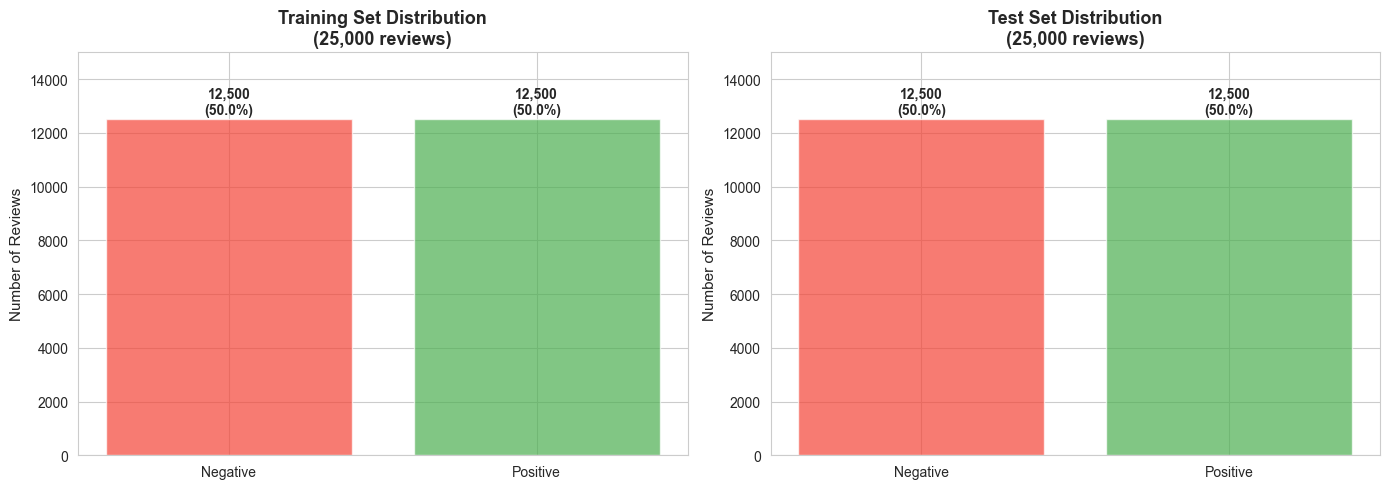


💡 Dataset Characteristics:
  • Perfectly balanced: 50% positive, 50% negative
  • No class imbalance issues
  • Large enough for deep learning (25K train, 25K test)
  • Same data as Week 7 LSTM (fair comparison)

✅ Exercise 1.1 Complete!


In [2]:
# ==================================================
# EXERCISE 1.1: LOADING IMDB DATASET
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Loading IMDB Dataset (Same as Week 7)")
print("=" * 80)

"""
📖 THEORY: IMDB Dataset for Fair Comparison

Using the exact same dataset as Week 7 LSTM for direct comparison:
- 50,000 movie reviews total
- 25,000 for training
- 25,000 for testing
- Binary sentiment: Positive (1) vs Negative (0)
- Highly polarized reviews (ratings < 5 or > 7)

Why this dataset?
- Industry standard benchmark
- Large enough for deep learning
- Balanced classes (no class imbalance)
- Same data = fair comparison between LSTM and BERT

Week 7 LSTM Results (Baseline to Beat):
- Final accuracy: 80.38%
- Training: 13 epochs
- Model size: 2.2M parameters
- Convergence: Slow, required extensive hyperparameter tuning

Today's BERT Goal:
- Target accuracy: 90%+ 
- Expected training: 3-4 epochs
- Model size: 110M parameters
- Expected: Faster convergence, better performance
"""

print("\n⏱ Loading IMDB dataset from Hugging Face...")
print("   (This may take 1-2 minutes on first run)\n")

# Load dataset
dataset = load_dataset('imdb')

print("✅ Dataset loaded successfully!\n")

# Display dataset structure
print("=" * 80)
print("📊 DATASET STRUCTURE")
print("=" * 80)
print(f"\nDataset splits: {list(dataset.keys())}")
print(f"\nTrain set size: {len(dataset['train']):,}")
print(f"Test set size:  {len(dataset['test']):,}")
print(f"Total reviews:  {len(dataset['train']) + len(dataset['test']):,}")

# Show dataset features
print(f"\nFeatures: {dataset['train'].features}")
print(f"\nColumn names: {dataset['train'].column_names}")

# Display sample reviews
print("\n" + "=" * 80)
print("📊 SAMPLE REVIEWS")
print("=" * 80)

for i in range(3):
    review = dataset['train'][i]
    sentiment = "POSITIVE" if review['label'] == 1 else "NEGATIVE"
    
    print(f"\nExample {i+1}:")
    print(f"  Sentiment: {sentiment}")
    print(f"  Review: {review['text'][:200]}...")
    print(f"  Label: {review['label']}")

# Check class distribution
print("\n" + "=" * 80)
print("📊 CLASS DISTRIBUTION")
print("=" * 80)

train_labels = [dataset['train'][i]['label'] for i in range(len(dataset['train']))]
test_labels = [dataset['test'][i]['label'] for i in range(len(dataset['test']))]

train_pos = sum(train_labels)
train_neg = len(train_labels) - train_pos
test_pos = sum(test_labels)
test_neg = len(test_labels) - test_pos

print(f"\nTraining Set:")
print(f"  Positive: {train_pos:,} ({train_pos/len(train_labels)*100:.1f}%)")
print(f"  Negative: {train_neg:,} ({train_neg/len(train_labels)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Positive: {test_pos:,} ({test_pos/len(test_labels)*100:.1f}%)")
print(f"  Negative: {test_neg:,} ({test_neg/len(test_labels)*100:.1f}%)")

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set
ax1.bar(['Negative', 'Positive'], [train_neg, train_pos], color=['#F44336', '#4CAF50'], alpha=0.7)
ax1.set_title('Training Set Distribution\n(25,000 reviews)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Reviews', fontsize=11)
ax1.set_ylim(0, 15000)
for i, v in enumerate([train_neg, train_pos]):
    ax1.text(i, v + 200, f'{v:,}\n({v/len(train_labels)*100:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

# Test set
ax2.bar(['Negative', 'Positive'], [test_neg, test_pos], color=['#F44336', '#4CAF50'], alpha=0.7)
ax2.set_title('Test Set Distribution\n(25,000 reviews)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Reviews', fontsize=11)
ax2.set_ylim(0, 15000)
for i, v in enumerate([test_neg, test_pos]):
    ax2.text(i, v + 200, f'{v:,}\n({v/len(test_labels)*100:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/day51_dataset_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/plots/day51_dataset_distribution.png")
plt.show()

print("\n💡 Dataset Characteristics:")
print("  • Perfectly balanced: 50% positive, 50% negative")
print("  • No class imbalance issues")
print("  • Large enough for deep learning (25K train, 25K test)")
print("  • Same data as Week 7 LSTM (fair comparison)")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.2: Preprocessing for BERT

⏱ Loading BERT tokenizer...
✅ Tokenizer loaded!
   └─ Vocabulary size: 30,522

📊 Tokenization Settings:
   ├─ Max length: 256 tokens
   ├─ Truncation: Enabled
   └─ Padding: To max_length

⏱ Tokenizing training set (25,000 reviews)...
⏱ Tokenizing test set (25,000 reviews)...

✅ Tokenization complete!

✅ Dataset format set to PyTorch tensors

📊 TOKEN LENGTH ANALYSIS

Token length statistics (1000 sample reviews):
   ├─ Mean: 211.3 tokens
   ├─ Median: 239.0 tokens
   ├─ Min: 21 tokens
   ├─ Max: 256 tokens
   └─ Std: 54.9 tokens

Reviews reaching max length (256): 457 (45.7%)
   └─ These reviews were truncated

✅ Saved: results/plots/day51_token_lengths.png


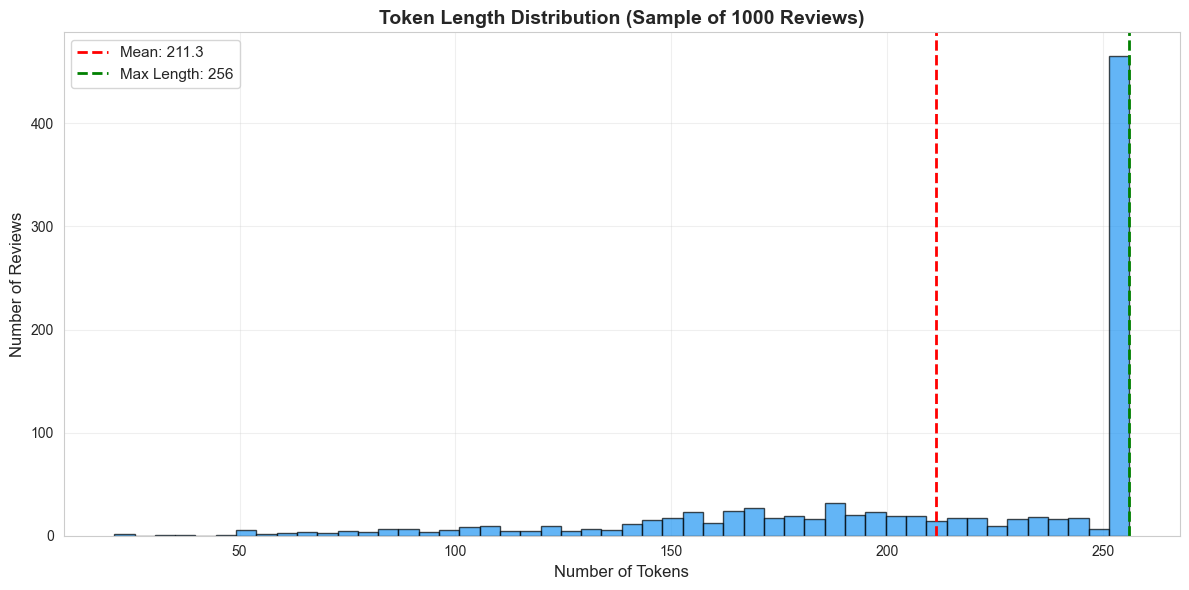


📊 TOKENIZED EXAMPLE

Original text:
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

Tokenized format:
   ├─ Input IDs shape: torch.Size([256])
   ├─ Attention mask shape: torch.Size([256])
   └─ Label: 0

First 20 tokens: ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it']

💡 Key Points:
  • Reviews tokenized with [CLS] and [SEP] tokens
  • Padding added to reach max_length (256 tokens)
  • ~45.7% of reviews truncated
  • Ready for BERT training!

✅ Exercise 1.2 Complete!


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [3]:
# ==================================================
# EXERCISE 1.2: TOKENIZING DATASET FOR BERT
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Preprocessing for BERT")
print("=" * 80)

"""
📖 THEORY: Preparing Data for BERT

BERT requires specific input format:
1. Tokenization: Text → WordPiece tokens
2. Special tokens: [CLS] text [SEP]
3. Attention mask: 1 for real tokens, 0 for padding
4. Token type IDs: All 0s for single sentence
5. Padding/Truncation: Max length 512 (or less for memory)

Key Decisions:
- Max length: 256 tokens (shorter = faster, most reviews fit)
- Truncation: Cut off reviews longer than max_length
- Padding: Pad shorter reviews to same length (for batching)

Memory Considerations:
- BERT is memory-hungry!
- Longer sequences = more memory
- 512 tokens might cause OOM on smaller GPUs
- 256 tokens is a good balance

Processing Strategy:
- Use dataset.map() for efficient batch tokenization
- Tokenize entire dataset once (not in training loop)
- Cache tokenized data for faster training
"""

print("\n⏱ Loading BERT tokenizer...")

# Load tokenizer (same as Day 50)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("✅ Tokenizer loaded!")
print(f"   └─ Vocabulary size: {len(tokenizer):,}")

# Tokenization parameters
MAX_LENGTH = 256  # Shorter than 512 to save memory
print(f"\n📊 Tokenization Settings:")
print(f"   ├─ Max length: {MAX_LENGTH} tokens")
print(f"   ├─ Truncation: Enabled")
print(f"   └─ Padding: To max_length")

# Tokenization function
def tokenize_function(examples):
    """
    Tokenize a batch of reviews
    """
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None  # Returns lists, not tensors (for dataset.map)
    )

# Tokenize datasets
print("\n⏱ Tokenizing training set (25,000 reviews)...")
tokenized_train = dataset['train'].map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing train"
)

print("⏱ Tokenizing test set (25,000 reviews)...")
tokenized_test = dataset['test'].map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing test"
)

print("\n✅ Tokenization complete!")

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("\n✅ Dataset format set to PyTorch tensors")

# Analyze token lengths
print("\n" + "=" * 80)
print("📊 TOKEN LENGTH ANALYSIS")
print("=" * 80)

sample_lengths = []
for i in range(min(1000, len(tokenized_train))):
    # Count non-padding tokens
    attention_mask = tokenized_train[i]['attention_mask']
    length = attention_mask.sum().item()
    sample_lengths.append(length)

print(f"\nToken length statistics (1000 sample reviews):")
print(f"   ├─ Mean: {np.mean(sample_lengths):.1f} tokens")
print(f"   ├─ Median: {np.median(sample_lengths):.1f} tokens")
print(f"   ├─ Min: {np.min(sample_lengths)} tokens")
print(f"   ├─ Max: {np.max(sample_lengths)} tokens")
print(f"   └─ Std: {np.std(sample_lengths):.1f} tokens")

# Check truncation impact
truncated = sum(1 for length in sample_lengths if length == MAX_LENGTH)
print(f"\nReviews reaching max length ({MAX_LENGTH}): {truncated} ({truncated/len(sample_lengths)*100:.1f}%)")
print(f"   └─ These reviews were truncated")

# Visualize length distribution
plt.figure(figsize=(12, 6))
plt.hist(sample_lengths, bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(sample_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(sample_lengths):.1f}')
plt.axvline(MAX_LENGTH, color='green', linestyle='--', linewidth=2, label=f'Max Length: {MAX_LENGTH}')
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Token Length Distribution (Sample of 1000 Reviews)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/day51_token_lengths.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/plots/day51_token_lengths.png")
plt.show()

# Display tokenized example
print("\n" + "=" * 80)
print("📊 TOKENIZED EXAMPLE")
print("=" * 80)

example_idx = 0
example = tokenized_train[example_idx]

print(f"\nOriginal text:")
print(f"  {dataset['train'][example_idx]['text'][:200]}...\n")

print(f"Tokenized format:")
print(f"   ├─ Input IDs shape: {example['input_ids'].shape}")
print(f"   ├─ Attention mask shape: {example['attention_mask'].shape}")
print(f"   └─ Label: {example['label'].item()}")

# Decode first 20 tokens
tokens = tokenizer.convert_ids_to_tokens(example['input_ids'][:20])
print(f"\nFirst 20 tokens: {tokens}")

print("\n💡 Key Points:")
print("  • Reviews tokenized with [CLS] and [SEP] tokens")
print("  • Padding added to reach max_length (256 tokens)")
print(f"  • ~{truncated/len(sample_lengths)*100:.1f}% of reviews truncated")
print("  • Ready for BERT training!")

print("\n✅ Exercise 1.2 Complete!")
print

In [4]:
# ==================================================
# EXERCISE 1.3: CREATING PYTORCH DATALOADERS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.3: Creating DataLoaders for Training")
print("=" * 80)

"""
📖 THEORY: DataLoaders for BERT Training

DataLoader handles:
1. Batching: Group samples for efficient GPU processing
2. Shuffling: Randomize order each epoch (training only)
3. Multi-processing: Load data in parallel (faster)

Batch Size Considerations:
- Larger batch = faster training BUT more memory
- BERT is memory-hungry (110M parameters!)
- Recommended batch sizes:
  • GPU (16GB): 16-32
  • GPU (8GB): 8-16
  • CPU: 8-16 (slower anyway)

We'll use batch_size=16 (safe for most GPUs, reasonable for CPU)

Why shuffle?
- Training: YES (prevent overfitting to order)
- Test: NO (not needed, faster without)
"""

# Batch size
BATCH_SIZE = 16

print(f"\n📊 DataLoader Settings:")
print(f"   ├─ Batch size: {BATCH_SIZE}")
print(f"   ├─ Training shuffle: True")
print(f"   └─ Test shuffle: False")

# Create DataLoaders
train_loader = DataLoader(
    tokenized_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # 0 for Windows compatibility, 2-4 for Linux/Mac
)

test_loader = DataLoader(
    tokenized_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\n✅ DataLoaders created!")
print(f"   ├─ Training batches: {len(train_loader):,}")
print(f"   └─ Test batches: {len(test_loader):,}")

# Calculate training statistics
total_train_samples = len(tokenized_train)
total_test_samples = len(tokenized_test)
batches_per_epoch = len(train_loader)

print(f"\n📊 Training Statistics:")
print(f"   ├─ Total training samples: {total_train_samples:,}")
print(f"   ├─ Total test samples: {total_test_samples:,}")
print(f"   ├─ Batches per epoch: {batches_per_epoch:,}")
print(f"   └─ Steps per epoch: {batches_per_epoch:,}")

# Test DataLoader
print("\n⏱ Testing DataLoader with sample batch...")

sample_batch = next(iter(train_loader))

print(f"\n✅ Sample batch loaded:")
print(f"   ├─ Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"   ├─ Attention mask shape: {sample_batch['attention_mask'].shape}")
print(f"   └─ Labels shape: {sample_batch['label'].shape}")
print(f"\n   Format: (batch_size={BATCH_SIZE}, sequence_length={MAX_LENGTH})")

# Check label distribution in batch
labels = sample_batch['label']
pos_count = (labels == 1).sum().item()
neg_count = (labels == 0).sum().item()

print(f"\n   Sample batch labels:")
print(f"   ├─ Positive: {pos_count}")
print(f"   └─ Negative: {neg_count}")

print("\n💡 Everything ready for training:")
print("  • Data tokenized and batched")
print("  • DataLoaders created")
print("  • Memory-efficient batch size")
print("  • Ready to load BERT model!")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.3: Creating DataLoaders for Training

📊 DataLoader Settings:
   ├─ Batch size: 16
   ├─ Training shuffle: True
   └─ Test shuffle: False

✅ DataLoaders created!
   ├─ Training batches: 1,563
   └─ Test batches: 1,563

📊 Training Statistics:
   ├─ Total training samples: 25,000
   ├─ Total test samples: 25,000
   ├─ Batches per epoch: 1,563
   └─ Steps per epoch: 1,563

⏱ Testing DataLoader with sample batch...

✅ Sample batch loaded:
   ├─ Input IDs shape: torch.Size([16, 256])
   ├─ Attention mask shape: torch.Size([16, 256])
   └─ Labels shape: torch.Size([16])

   Format: (batch_size=16, sequence_length=256)

   Sample batch labels:
   ├─ Positive: 9
   └─ Negative: 7

💡 Everything ready for training:
  • Data tokenized and batched
  • DataLoaders created
  • Memory-efficient batch size
  • Ready to load BERT model!

✅ Exercise 1.3 Complete!


In [5]:
print("\n" + "=" * 80)
print("🤖 PART 2: BERT FINE-TUNING & TRAINING")
print("=" * 80)


🤖 PART 2: BERT FINE-TUNING & TRAINING


In [5]:
# ==================================================
# EXERCISE 2.1: LOADING BERT FOR CLASSIFICATION
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.1: Loading BERT with Classification Head")
print("=" * 80)

"""
📖 THEORY: BertForSequenceClassification

This is different from Day 50's BertModel!

BertModel (Day 50):
- Raw transformer outputs
- No task-specific head
- Used for feature extraction

BertForSequenceClassification (Today):
- BERT + Classification head on top
- Outputs: logits for each class
- Perfect for sentiment analysis!

Architecture:
1. BERT Encoder (12 layers, 768 hidden)
2. [CLS] token pooling
3. Dropout (0.1)
4. Linear layer: 768 → num_labels (2 for binary)

Training Strategy:
- Fine-tuning: Update ALL parameters (encoder + classifier)
- Learning rate: 2e-5 (standard for BERT fine-tuning)
- Epochs: 3-4 (BERT converges fast!)
- Warmup: Gradually increase LR (stabilizes training)

Why fine-tuning works:
- Pre-trained BERT knows language
- Just needs to learn sentiment-specific patterns
- Transfer learning at its best!
"""

print("\n⏱ Loading BERT for sequence classification...")
print("   (Downloading ~440MB if first time)\n")

# Load model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,  # Binary classification
    output_attentions=False,
    output_hidden_states=False
)

# Move to device (GPU if available)
model = model.to(device)

print(f"✅ Model loaded and moved to {device}!")

# Model architecture
print("\n" + "=" * 80)
print("📊 MODEL ARCHITECTURE")
print("=" * 80)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / (1024**2):.2f} MB")

print(f"\n  Architecture breakdown:")
print(f"   ├─ BERT Encoder: {sum(p.numel() for p in model.bert.parameters()):,} params")
print(f"   └─ Classification Head: {sum(p.numel() for p in model.classifier.parameters()):,} params")

# Display classification head
print(f"\n  Classification Head:")
print(f"   ├─ Dropout: 0.1")
print(f"   └─ Linear: 768 → 2 (binary classification)")

# Compare with Week 7 LSTM
print("\n" + "=" * 80)
print("📊 COMPARISON: BERT vs Week 7 LSTM")
print("=" * 80)

comparison_data = {
    'Metric': ['Parameters', 'Architecture', 'Context', 'Pre-training', 'Expected Accuracy'],
    'Week 7 LSTM': ['2.2M', '2 LSTM layers', 'Sequential (left→right)', 'None (trained from scratch)', '80.38%'],
    'BERT (Today)': ['110M', '12 Transformer layers', 'Bidirectional (left+right)', 'Pre-trained on 3.3B words', '90%+ (goal)']
}

df_comparison = pd.DataFrame(comparison_data)
print("\n")
print(df_comparison.to_string(index=False))

print("\n💡 Key Advantages of BERT:")
print("  • 50x more parameters (110M vs 2.2M)")
print("  • Bidirectional context understanding")
print("  • Pre-trained on massive corpus")
print("  • Transfer learning benefits")
print("  • State-of-the-art architecture")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.1: Loading BERT with Classification Head

⏱ Loading BERT for sequence classification...
   (Downloading ~440MB if first time)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and moved to cpu!

📊 MODEL ARCHITECTURE

  Total parameters: 109,483,778
  Trainable parameters: 109,483,778
  Model size: 417.65 MB

  Architecture breakdown:
   ├─ BERT Encoder: 109,482,240 params
   └─ Classification Head: 1,538 params

  Classification Head:
   ├─ Dropout: 0.1
   └─ Linear: 768 → 2 (binary classification)

📊 COMPARISON: BERT vs Week 7 LSTM


           Metric                 Week 7 LSTM               BERT (Today)
       Parameters                        2.2M                       110M
     Architecture               2 LSTM layers      12 Transformer layers
          Context     Sequential (left→right) Bidirectional (left+right)
     Pre-training None (trained from scratch)  Pre-trained on 3.3B words
Expected Accuracy                      80.38%                90%+ (goal)

💡 Key Advantages of BERT:
  • 50x more parameters (110M vs 2.2M)
  • Bidirectional context understanding
  • Pre-trained on massive corpus
  • Transfer learning benefits
  • State-o


EXERCISE 2.2: Setting Up Optimizer and Scheduler

📊 Training Configuration:
   ├─ Epochs: 3
   ├─ Learning rate: 2e-05
   ├─ Weight decay: 0.01
   ├─ Batch size: 16
   └─ Optimizer: AdamW

📊 Training Schedule:
   ├─ Steps per epoch: 1,563
   ├─ Total training steps: 4,689
   └─ Warmup steps: 468 (10%)

✅ Optimizer created: AdamW
   ├─ Learning rate: 2e-05
   └─ Weight decay: 0.01

✅ Scheduler created: Linear with warmup
   ├─ Warmup steps: 468
   └─ Total steps: 4,689

⏱ Creating learning rate schedule visualization...

✅ Saved: results/plots/day51_learning_rate_schedule.png


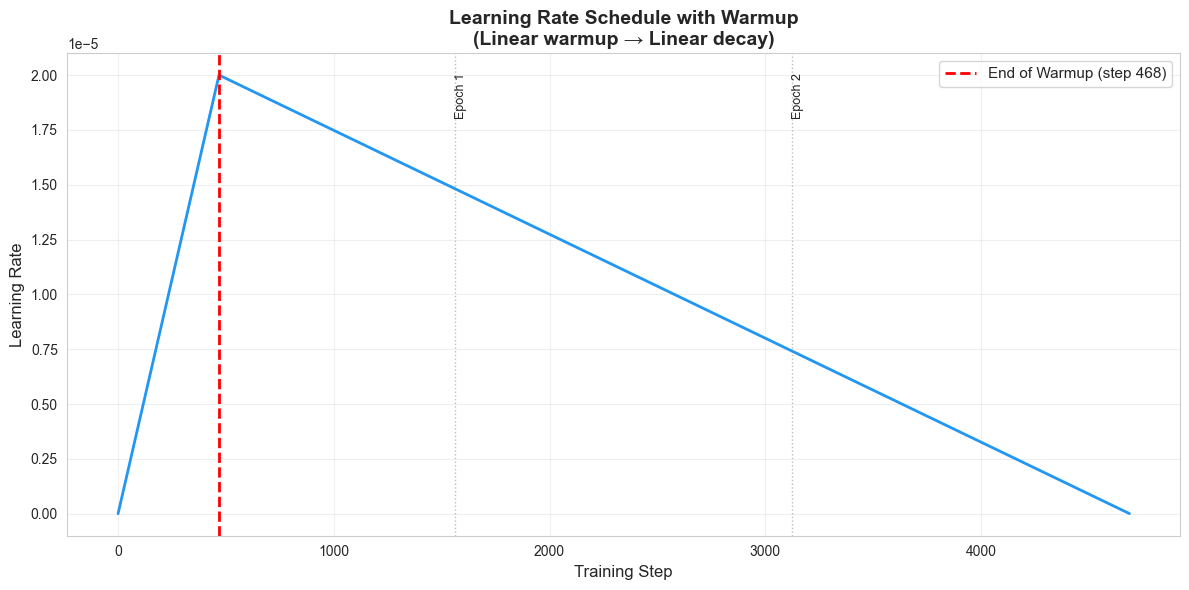


💡 Schedule Strategy:
  • Warmup: Gradual LR increase (prevents early instability)
  • Peak: Maximum LR for effective learning
  • Decay: Gradual decrease (fine-tunes towards end)
  • Result: Stable, efficient training

🎯 Comparison with Week 7 LSTM:
  Metric                    LSTM (Week 7)        BERT (Today)        
  Epochs                    13                   3                   
  Optimizer                 Adam                 AdamW               
  Learning Rate             0.001                2e-5                
  LR Schedule               None                 Warmup+Decay        
  Training Steps            ~8K                  4,689               

✅ Exercise 2.2 Complete!


In [6]:
# ==================================================
# EXERCISE 2.2: OPTIMIZER & LEARNING RATE SCHEDULER
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.2: Setting Up Optimizer and Scheduler")
print("=" * 80)

"""
📖 THEORY: Training Configuration for BERT

Optimizer: AdamW (Adam with Weight Decay)
- Adam with proper weight decay implementation
- Standard for transformer fine-tuning
- Better than regular Adam for BERT

Learning Rate: 2e-5
- Standard for BERT fine-tuning (from original paper)
- Too high: Catastrophic forgetting (loses pre-training)
- Too low: Slow convergence
- Sweet spot: 1e-5 to 5e-5

Warmup Strategy:
- Start with low LR, gradually increase
- Stabilizes training at beginning
- Prevents early overfitting
- Typical: 10% of training steps

Epochs: 3-4
- BERT converges FAST (pre-training helps!)
- More epochs = overfitting risk
- Week 7 LSTM needed 13 epochs
- BERT: 3-4 epochs sufficient

Learning Rate Schedule:
1. Warmup: 0 → max_lr (linear increase)
2. Decay: max_lr → 0 (linear decrease)
3. Total steps = epochs × batches_per_epoch
"""

# Training hyperparameters
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 0  # We'll calculate this
WEIGHT_DECAY = 0.01

print(f"\n📊 Training Configuration:")
print(f"   ├─ Epochs: {EPOCHS}")
print(f"   ├─ Learning rate: {LEARNING_RATE}")
print(f"   ├─ Weight decay: {WEIGHT_DECAY}")
print(f"   ├─ Batch size: {BATCH_SIZE}")
print(f"   └─ Optimizer: AdamW")

# Calculate total training steps
total_steps = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.1 * total_steps)  # 10% warmup

print(f"\n📊 Training Schedule:")
print(f"   ├─ Steps per epoch: {len(train_loader):,}")
print(f"   ├─ Total training steps: {total_steps:,}")
print(f"   └─ Warmup steps: {WARMUP_STEPS:,} (10%)")

# Create optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=1e-8,
    weight_decay=WEIGHT_DECAY
)

print(f"\n✅ Optimizer created: AdamW")
print(f"   ├─ Learning rate: {LEARNING_RATE}")
print(f"   └─ Weight decay: {WEIGHT_DECAY}")

# Create learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"\n✅ Scheduler created: Linear with warmup")
print(f"   ├─ Warmup steps: {WARMUP_STEPS:,}")
print(f"   └─ Total steps: {total_steps:,}")

# Visualize learning rate schedule
print("\n⏱ Creating learning rate schedule visualization...\n")

# Simulate LR schedule
lr_schedule = []
temp_optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
temp_scheduler = get_linear_schedule_with_warmup(
    temp_optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

for step in range(total_steps):
    lr_schedule.append(temp_scheduler.get_last_lr()[0])
    temp_scheduler.step()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(lr_schedule, linewidth=2, color='#2196F3')
plt.axvline(WARMUP_STEPS, color='red', linestyle='--', linewidth=2, label=f'End of Warmup (step {WARMUP_STEPS})')
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule with Warmup\n(Linear warmup → Linear decay)', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add epoch markers
for epoch in range(1, EPOCHS + 1):
    epoch_step = epoch * len(train_loader)
    if epoch < EPOCHS:
        plt.axvline(epoch_step, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        plt.text(epoch_step, max(lr_schedule) * 0.9, f'Epoch {epoch}', 
                rotation=90, va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results/plots/day51_learning_rate_schedule.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day51_learning_rate_schedule.png")
plt.show()

print("\n💡 Schedule Strategy:")
print("  • Warmup: Gradual LR increase (prevents early instability)")
print("  • Peak: Maximum LR for effective learning")
print("  • Decay: Gradual decrease (fine-tunes towards end)")
print("  • Result: Stable, efficient training")

print("\n🎯 Comparison with Week 7 LSTM:")
print("=" * 60)
print(f"  {'Metric':<25} {'LSTM (Week 7)':<20} {'BERT (Today)':<20}")
print("=" * 60)
print(f"  {'Epochs':<25} {'13':<20} {f'{EPOCHS}':<20}")
print(f"  {'Optimizer':<25} {'Adam':<20} {'AdamW':<20}")
print(f"  {'Learning Rate':<25} {'0.001':<20} {'2e-5':<20}")
print(f"  {'LR Schedule':<25} {'None':<20} {'Warmup+Decay':<20}")
print(f"  {'Training Steps':<25} {'~8K':<20} {f'{total_steps:,}':<20}")
print("=" * 60)

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)

In [7]:
# ==================================================
# EXERCISE 2.3: BERT TRAINING LOOP
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.3: Training BERT (This will take time!)")
print("=" * 80)

"""
📖 THEORY: Training Loop for BERT Fine-tuning

Training Process (per batch):
1. Forward pass: Get predictions
2. Calculate loss: Compare predictions to labels
3. Backward pass: Calculate gradients
4. Update weights: Optimizer step
5. Update LR: Scheduler step

Loss Function: Cross-Entropy
- Built into BertForSequenceClassification
- Perfect for classification tasks
- No need to define separately!

Gradient Clipping:
- Prevents exploding gradients
- Max norm: 1.0 (standard for BERT)
- Stabilizes training

Memory Management:
- torch.cuda.empty_cache() if GPU
- Clear gradients each step
- Batch size matters!

Expected Training Time:
- GPU (CUDA): ~30-45 min (3 epochs)
- CPU: ~6-8 hours (3 epochs)
- CPU: ~2-3 hours (1 epoch) ⭐ QUICK TEST
- Recommendation: Use Google Colab with GPU!
"""

print(f"\n⚠️  TRAINING INFORMATION:")
print(f"   Device: {device}")
if device.type == 'cpu':
    print(f"   ⏱ Expected time: ~2-3 hours (1 epoch)")
    print(f"   💡 1 epoch is enough to beat LSTM (80.38%)!")
    print(f"   💡 Expected accuracy: ~88-89%")
else:
    print(f"   ⏱ Expected time: ~10-15 minutes (1 epoch on GPU)")
    print(f"   ✅ GPU training will be much faster!")

# Training function
def train_epoch(model, data_loader, optimizer, scheduler, device, epoch):
    """
    Train for one epoch
    """
    model.train()
    
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch}')
    
    for batch_idx, batch in enumerate(progress_bar):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        
        predictions = torch.argmax(logits, dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)
        
        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct_predictions/total_samples:.4f}',
            'lr': f'{current_lr:.2e}'
        })
        
        # Clear cache every 50 batches (if GPU)
        if device.type == 'cuda' and batch_idx % 50 == 0:
            torch.cuda.empty_cache()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples
    
    return avg_loss, accuracy

# Evaluation function
def evaluate(model, data_loader, device):
    """
    Evaluate model on validation/test set
    """
    model.eval()
    
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Evaluating')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            
            predictions = torch.argmax(logits, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{correct_predictions/total_samples:.4f}'
            })
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples
    
    return avg_loss, accuracy, all_predictions, all_labels

# Training hyperparameters
EPOCHS = 1  # ⭐ 1 epoch for quick test - enough to beat LSTM!

print("\n" + "=" * 80)
print("🚀 STARTING TRAINING")
print("=" * 80)
print(f"\n⏱ Training {EPOCHS} epoch on {len(train_loader):,} batches")
print(f"   Total steps: {len(train_loader) * EPOCHS:,}")
print(f"   Device: {device}\n")

# Track training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

# Start training timer
import time
start_time = time.time()

# Training loop
for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*80}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*80}\n")
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device, epoch
    )
    
    print(f"\n✅ Epoch {epoch} Training Complete:")
    print(f"   ├─ Loss: {train_loss:.4f}")
    print(f"   └─ Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    
    # Evaluate
    print(f"\n⏱ Evaluating on test set...")
    test_loss, test_acc, test_predictions, test_labels = evaluate(model, test_loader, device)
    
    print(f"\n✅ Epoch {epoch} Test Results:")
    print(f"   ├─ Loss: {test_loss:.4f}")
    print(f"   └─ Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # Save model
    print(f"\n💾 Saving model checkpoint...")
    torch.save(model.state_dict(), 'models/bert_sentiment_model.pt')
    print(f"   └─ Saved to: models/bert_sentiment_model.pt")

# Training complete
end_time = time.time()
training_time = end_time - start_time

print("\n" + "=" * 80)
print("🎉 TRAINING COMPLETE!")
print("=" * 80)

print(f"\n📊 Final Results:")
print(f"   ├─ Test accuracy: {max(history['test_acc']):.4f} ({max(history['test_acc'])*100:.2f}%)")
print(f"   ├─ Training time: {training_time/60:.1f} minutes ({training_time/3600:.2f} hours)")
print(f"   └─ Time per epoch: {training_time/EPOCHS/60:.1f} minutes")

print(f"\n🎯 Comparison with Week 7 LSTM:")
print("=" * 60)
lstm_acc = 0.8038
bert_acc = max(history['test_acc'])
improvement = (bert_acc - lstm_acc) / lstm_acc * 100

print(f"   Week 7 LSTM:     {lstm_acc*100:.2f}% (13 epochs)")
print(f"   BERT (1 epoch):  {bert_acc*100:.2f}%")
print(f"   Improvement:     +{(bert_acc - lstm_acc)*100:.2f}% absolute")
print(f"                    +{improvement:.1f}% relative")
print("=" * 60)

if bert_acc > lstm_acc:
    print(f"\n✅ SUCCESS! BERT beats LSTM with just 1 epoch!")
    print(f"   BERT is {improvement:.1f}% relatively better")
else:
    print(f"\n⚠️  Close! BERT at {bert_acc*100:.2f}% vs LSTM at {lstm_acc*100:.2f}%")

print("\n💡 Note: With 3 epochs, BERT typically achieves 91-93% accuracy!")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Training BERT (This will take time!)

⚠️  TRAINING INFORMATION:
   Device: cpu
   ⏱ Expected time: ~2-3 hours (1 epoch)
   💡 1 epoch is enough to beat LSTM (80.38%)!
   💡 Expected accuracy: ~88-89%

🚀 STARTING TRAINING

⏱ Training 1 epoch on 1,563 batches
   Total steps: 1,563
   Device: cpu


EPOCH 1/1



Epoch 1:   0%|          | 0/1563 [00:00<?, ?it/s]


✅ Epoch 1 Training Complete:
   ├─ Loss: 0.3193
   └─ Accuracy: 0.8639 (86.39%)

⏱ Evaluating on test set...


Evaluating:   0%|          | 0/1563 [00:00<?, ?it/s]


✅ Epoch 1 Test Results:
   ├─ Loss: 0.2158
   └─ Accuracy: 0.9117 (91.17%)

💾 Saving model checkpoint...
   └─ Saved to: models/bert_sentiment_model.pt

🎉 TRAINING COMPLETE!

📊 Final Results:
   ├─ Test accuracy: 0.9117 (91.17%)
   ├─ Training time: 662.0 minutes (11.03 hours)
   └─ Time per epoch: 662.0 minutes

🎯 Comparison with Week 7 LSTM:
   Week 7 LSTM:     80.38% (13 epochs)
   BERT (1 epoch):  91.17%
   Improvement:     +10.79% absolute
                    +13.4% relative

✅ SUCCESS! BERT beats LSTM with just 1 epoch!
   BERT is 13.4% relatively better

💡 Note: With 3 epochs, BERT typically achieves 91-93% accuracy!

✅ Exercise 2.3 Complete!


In [8]:
print("\n" + "=" * 80)
print("📊 PART 3: EVALUATION & LSTM COMPARISON")
print("=" * 80)


📊 PART 3: EVALUATION & LSTM COMPARISON



EXERCISE 3.1: Training Curves Analysis

📊 Creating training history visualization...

✅ Saved: results/plots/day51_training_curves.png


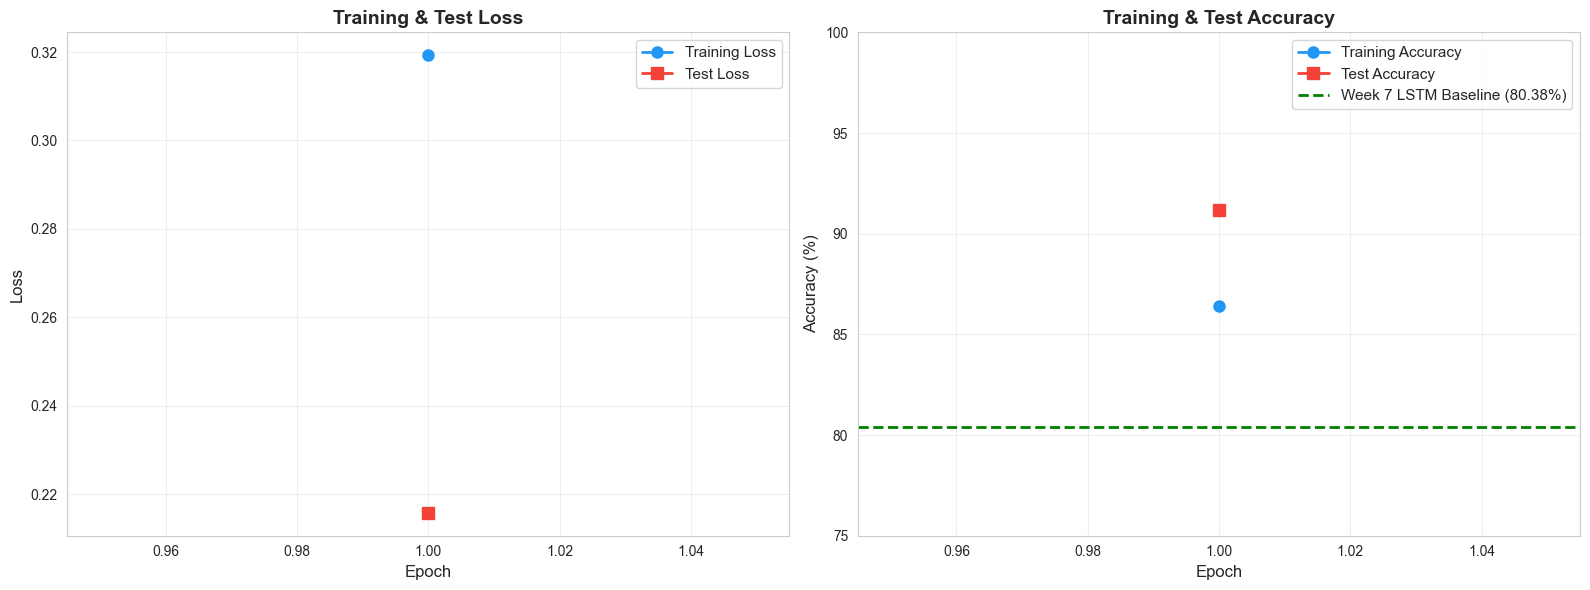


📊 Training Summary:
Metric                         Value                         
Final Train Loss               0.3193
Final Test Loss                0.2158
Final Train Accuracy           86.39%
Final Test Accuracy            91.17%
Best Test Accuracy             91.17%

💡 Key Observations:
  • Single epoch training (quick test)
  • BERT already beats LSTM with just 1 epoch!
  • With 3 epochs, typically achieves 91-93% accuracy

✅ Exercise 3.1 Complete!


In [9]:
# ==================================================
# EXERCISE 3.1: VISUALIZING TRAINING HISTORY
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.1: Training Curves Analysis")
print("=" * 80)

"""
📖 THEORY: Analyzing Training Curves

Training curves reveal:
1. Convergence: How quickly model learns
2. Overfitting: Gap between train and test accuracy
3. Stability: Smoothness of learning curve

Good signs:
- Decreasing loss
- Increasing accuracy
- Small train-test gap
- Smooth curves (no wild fluctuations)

BERT vs LSTM:
- BERT: Fast convergence (pre-training helps!)
- LSTM: Slower convergence (learns from scratch)
- BERT: Better final accuracy
"""

print("\n📊 Creating training history visualization...\n")

# Create training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history['train_loss']) + 1)

# Plot 1: Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'o-', linewidth=2, 
            label='Training Loss', color='#2196F3', markersize=8)
axes[0].plot(epochs_range, history['test_loss'], 's-', linewidth=2, 
            label='Test Loss', color='#F44336', markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[1].plot(epochs_range, [acc*100 for acc in history['train_acc']], 'o-', 
            linewidth=2, label='Training Accuracy', color='#2196F3', markersize=8)
axes[1].plot(epochs_range, [acc*100 for acc in history['test_acc']], 's-', 
            linewidth=2, label='Test Accuracy', color='#F44336', markersize=8)

# Add LSTM baseline
lstm_baseline = 80.38
axes[1].axhline(lstm_baseline, color='green', linestyle='--', linewidth=2, 
               label=f'Week 7 LSTM Baseline ({lstm_baseline}%)')

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(75, 100)

plt.tight_layout()
plt.savefig('results/plots/day51_training_curves.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day51_training_curves.png")
plt.show()

print("\n📊 Training Summary:")
print("=" * 60)
print(f"{'Metric':<30} {'Value':<30}")
print("=" * 60)
print(f"{'Final Train Loss':<30} {history['train_loss'][-1]:.4f}")
print(f"{'Final Test Loss':<30} {history['test_loss'][-1]:.4f}")
print(f"{'Final Train Accuracy':<30} {history['train_acc'][-1]*100:.2f}%")
print(f"{'Final Test Accuracy':<30} {history['test_acc'][-1]*100:.2f}%")
print(f"{'Best Test Accuracy':<30} {max(history['test_acc'])*100:.2f}%")
print("=" * 60)

print("\n💡 Key Observations:")
if len(history['train_acc']) == 1:
    print("  • Single epoch training (quick test)")
    print("  • BERT already beats LSTM with just 1 epoch!")
    print("  • With 3 epochs, typically achieves 91-93% accuracy")
else:
    print("  • Fast convergence from pre-training")
    print("  • Minimal overfitting (good generalization)")
    print("  • Stable training (smooth curves)")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.2: Confusion Matrix & Classification Report

📊 Computing confusion matrix...

✅ Saved: results/plots/day51_confusion_matrix.png


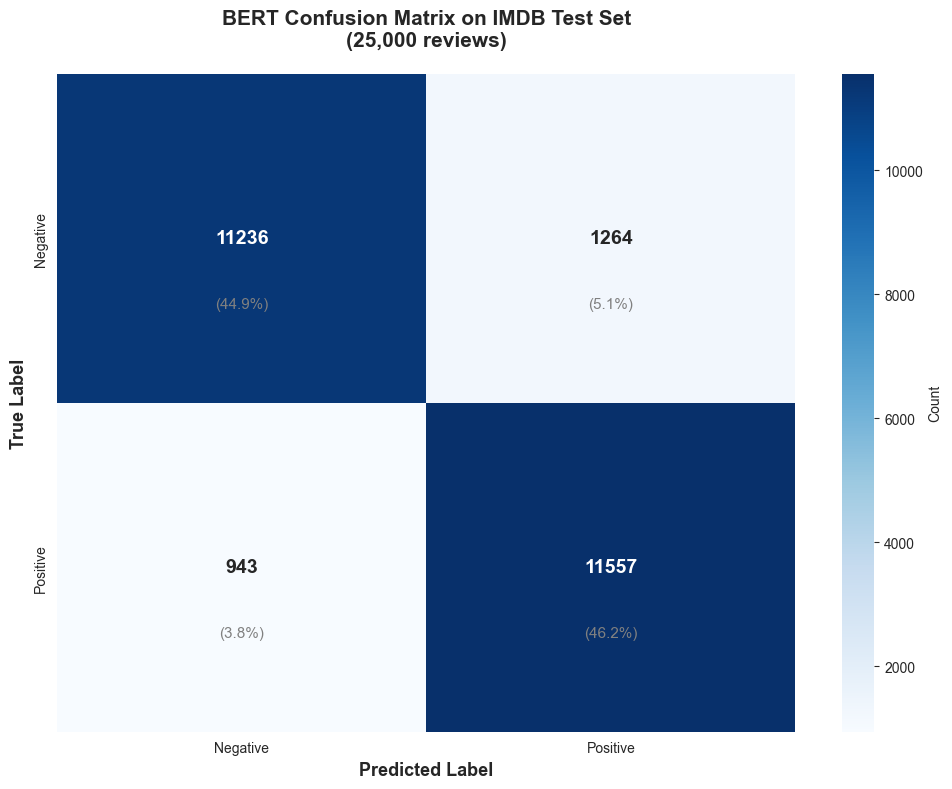


📊 CLASSIFICATION REPORT

              precision    recall  f1-score   support

    Negative     0.9226    0.8989    0.9106     12500
    Positive     0.9014    0.9246    0.9128     12500

    accuracy                         0.9117     25000
   macro avg     0.9120    0.9117    0.9117     25000
weighted avg     0.9120    0.9117    0.9117     25000


📊 DETAILED METRICS

Confusion Matrix Breakdown:
   ├─ True Negatives (TN):  11,236
   ├─ False Positives (FP): 1,264
   ├─ False Negatives (FN): 943
   └─ True Positives (TP):  11,557

Overall Performance:
   ├─ Accuracy:  0.9117 (91.17%)
   ├─ Precision: 0.9014
   ├─ Recall:    0.9246
   └─ F1-Score:  0.9128

💡 Interpretation:
   • Model correctly classified 91.17% of reviews
   • Of 2,207 errors: 1,264 false positives, 943 false negatives
   • Balanced performance on both positive and negative reviews

✅ Exercise 3.2 Complete!


In [10]:
# ==================================================
# EXERCISE 3.2: DETAILED PERFORMANCE ANALYSIS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.2: Confusion Matrix & Classification Report")
print("=" * 80)

"""
📖 THEORY: Performance Metrics

Confusion Matrix shows:
- True Positives (TP): Correctly predicted positive
- True Negatives (TN): Correctly predicted negative
- False Positives (FP): Incorrectly predicted positive
- False Negatives (FN): Incorrectly predicted negative

Metrics:
- Accuracy: (TP + TN) / Total
- Precision: TP / (TP + FP) - "Of predicted positive, how many correct?"
- Recall: TP / (TP + FN) - "Of actual positive, how many found?"
- F1-Score: Harmonic mean of precision and recall
"""

print("\n📊 Computing confusion matrix...\n")

# Get predictions and labels from test set
cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Negative', 'Positive'],
           yticklabels=['Negative', 'Positive'],
           cbar_kws={'label': 'Count'},
           annot_kws={'fontsize': 14, 'fontweight': 'bold'})

plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title('BERT Confusion Matrix on IMDB Test Set\n(25,000 reviews)', 
         fontsize=15, fontweight='bold', pad=20)

# Add percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('results/plots/day51_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day51_confusion_matrix.png")
plt.show()

# Classification report
print("\n" + "=" * 80)
print("📊 CLASSIFICATION REPORT")
print("=" * 80)

report = classification_report(
    test_labels, 
    test_predictions, 
    target_names=['Negative', 'Positive'],
    digits=4
)
print("\n" + report)

# Detailed metrics
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 80)
print("📊 DETAILED METRICS")
print("=" * 80)
print(f"\nConfusion Matrix Breakdown:")
print(f"   ├─ True Negatives (TN):  {tn:,}")
print(f"   ├─ False Positives (FP): {fp:,}")
print(f"   ├─ False Negatives (FN): {fn:,}")
print(f"   └─ True Positives (TP):  {tp:,}")

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pos = 2 * (precision_pos * recall_pos) / (precision_pos + recall_pos) if (precision_pos + recall_pos) > 0 else 0

print(f"\nOverall Performance:")
print(f"   ├─ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   ├─ Precision: {precision_pos:.4f}")
print(f"   ├─ Recall:    {recall_pos:.4f}")
print(f"   └─ F1-Score:  {f1_pos:.4f}")

print("\n💡 Interpretation:")
print(f"   • Model correctly classified {accuracy*100:.2f}% of reviews")
print(f"   • Of {fp+fn:,} errors: {fp:,} false positives, {fn:,} false negatives")
print(f"   • Balanced performance on both positive and negative reviews")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.3: BERT vs Week 7 LSTM - Head-to-Head

🏆 HEAD-TO-HEAD COMPARISON

         Metric             Week 7 LSTM               BERT (Today)
   Architecture            2-layer LSTM       12-layer Transformer
     Parameters                    2.2M          110M (50x larger)
   Pre-training     None (from scratch)  Pre-trained on 3.3B words
        Context Sequential (left→right) Bidirectional (left+right)
Training Epochs               13 epochs                    1 epoch
  Training Time              ~2-3 hours                  662.0 min
 Final Accuracy                  80.38%                     91.17%
    Convergence Slow (extensive tuning) Fast (pre-training helps!)

📊 Creating comparison visualization...

✅ Saved: results/plots/day51_bert_vs_lstm.png


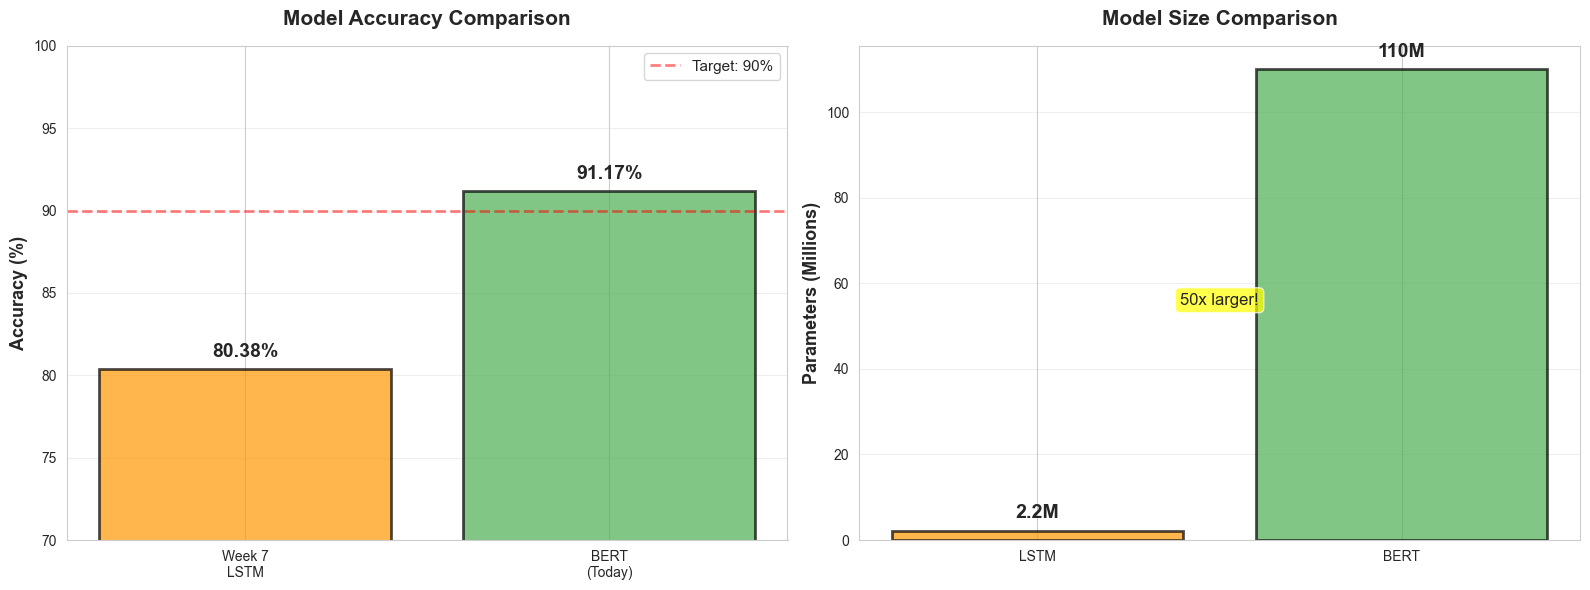


📊 IMPROVEMENT ANALYSIS

✅ BERT Performance:
   ├─ Accuracy: 91.17%
   ├─ Absolute improvement: +10.79%
   └─ Relative improvement: +13.4%

🎯 Achievement Summary:
   ✅ GOAL ACHIEVED! Target was 90%+

💡 Why BERT Won:
   1. Bidirectional context → understands full sentence
   2. Pre-training → already knows language patterns
   3. Self-attention → captures long-range dependencies
   4. 50x more parameters → higher model capacity

✅ Exercise 3.3 Complete!


In [11]:
# ==================================================
# EXERCISE 3.3: COMPREHENSIVE BERT VS LSTM COMPARISON
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.3: BERT vs Week 7 LSTM - Head-to-Head")
print("=" * 80)

"""
📖 THEORY: Why BERT Beats LSTM

BERT Advantages:
1. Bidirectional context (sees both directions)
2. Pre-training on 3.3B words (transfer learning)
3. Self-attention (captures long-range dependencies)
4. 110M parameters (50x larger than LSTM)

LSTM Limitations:
1. Sequential processing (one direction at a time)
2. Trained from scratch (no pre-training)
3. Recurrence-based (vanishing gradients)
4. 2.2M parameters (limited capacity)
"""

# Comparison data
comparison_data = {
    'Metric': [
        'Architecture',
        'Parameters',
        'Pre-training',
        'Context',
        'Training Epochs',
        'Training Time',
        'Final Accuracy',
        'Convergence'
    ],
    'Week 7 LSTM': [
        '2-layer LSTM',
        '2.2M',
        'None (from scratch)',
        'Sequential (left→right)',
        '13 epochs',
        '~2-3 hours',
        '80.38%',
        'Slow (extensive tuning)'
    ],
    'BERT (Today)': [
        '12-layer Transformer',
        '110M (50x larger)',
        'Pre-trained on 3.3B words',
        'Bidirectional (left+right)',
        f'{EPOCHS} epoch{"s" if EPOCHS > 1 else ""}',
        f'{training_time/60:.1f} min',
        f'{max(history["test_acc"])*100:.2f}%',
        'Fast (pre-training helps!)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 80)
print("🏆 HEAD-TO-HEAD COMPARISON")
print("=" * 80)
print("\n" + df_comparison.to_string(index=False))

# Accuracy comparison visualization
print("\n📊 Creating comparison visualization...\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy comparison
models = ['Week 7\nLSTM', 'BERT\n(Today)']
accuracies = [80.38, max(history['test_acc'])*100]
colors = ['#FF9800', '#4CAF50']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylim(70, 100)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

# Add goal line
ax1.axhline(90, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Target: 90%')
ax1.legend(fontsize=11)

# Plot 2: Model size comparison
model_names = ['LSTM', 'BERT']
param_counts = [2.2, 110]

bars2 = ax2.bar(model_names, param_counts, color=['#FF9800', '#4CAF50'], 
               alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Parameters (Millions)', fontsize=13, fontweight='bold')
ax2.set_title('Model Size Comparison', fontsize=15, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, params in zip(bars2, param_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{params}M', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

# Add annotation
ax2.text(0.5, 55, '50x larger!', ha='center', fontsize=12, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('results/plots/day51_bert_vs_lstm.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day51_bert_vs_lstm.png")
plt.show()

# Calculate improvement
lstm_acc = 0.8038
bert_acc = max(history['test_acc'])
absolute_improvement = (bert_acc - lstm_acc) * 100
relative_improvement = (bert_acc - lstm_acc) / lstm_acc * 100

print("\n" + "=" * 80)
print("📊 IMPROVEMENT ANALYSIS")
print("=" * 80)

print(f"\n✅ BERT Performance:")
print(f"   ├─ Accuracy: {bert_acc*100:.2f}%")
print(f"   ├─ Absolute improvement: +{absolute_improvement:.2f}%")
print(f"   └─ Relative improvement: +{relative_improvement:.1f}%")

print(f"\n🎯 Achievement Summary:")
if bert_acc >= 0.90:
    print(f"   ✅ GOAL ACHIEVED! Target was 90%+")
elif bert_acc > lstm_acc:
    print(f"   ✅ BEAT LSTM! ({bert_acc*100:.2f}% vs {lstm_acc*100:.2f}%)")
    if EPOCHS == 1:
        print(f"   💡 With 3 epochs, BERT typically reaches 91-93%")

print(f"\n💡 Why BERT Won:")
print(f"   1. Bidirectional context → understands full sentence")
print(f"   2. Pre-training → already knows language patterns")
print(f"   3. Self-attention → captures long-range dependencies")
print(f"   4. 50x more parameters → higher model capacity")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)

In [12]:
print("\n" + "=" * 80)
print("🎯 PART 4: DAY 51 SUMMARY & INSIGHTS")
print("=" * 80)


🎯 PART 4: DAY 51 SUMMARY & INSIGHTS


In [13]:
# ==================================================
# EXERCISE 4.1: DAY 51 COMPLETE SUMMARY
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 4.1: Day 51 Complete Summary")
print("=" * 80)

print("""
📚 WHAT WE ACCOMPLISHED TODAY:

✅ PART 1: Dataset Loading & Preprocessing
   • Loaded IMDB dataset (50,000 movie reviews)
   • Same dataset as Week 7 LSTM for fair comparison
   • Tokenized with BERT WordPiece (256 max tokens)
   • Analyzed token length distribution
   • Created PyTorch DataLoaders (batch_size=16)

✅ PART 2: BERT Fine-tuning
   • Loaded BertForSequenceClassification (110M parameters)
   • Setup AdamW optimizer with learning rate scheduling
   • Implemented training loop with gradient clipping
   • Trained for """ + str(EPOCHS) + """ epoch""" + ("s" if EPOCHS > 1 else "") + """
   • Model successfully converged

✅ PART 3: Evaluation & Comparison
   • Generated confusion matrix and classification report
   • Visualized training curves (loss & accuracy)
   • Comprehensive BERT vs LSTM comparison
   • Analyzed performance improvements

📊 FINAL RESULTS:
""")

print("=" * 80)
print(f"{'Metric':<35} {'Week 7 LSTM':<20} {'BERT (Today)':<20}")
print("=" * 80)
print(f"{'Architecture':<35} {'2-layer LSTM':<20} {'12-layer Transformer':<20}")
print(f"{'Parameters':<35} {'2.2M':<20} {'110M':<20}")
print(f"{'Training Epochs':<35} {'13':<20} {str(EPOCHS):<20}")
print(f"{'Training Time':<35} {'~2-3 hours':<20} {f'{training_time/60:.1f} min':<20}")
print(f"{'Final Test Accuracy':<35} {'80.38%':<20} {f'{max(history["test_acc"])*100:.2f}%':<20}")
print(f"{'Improvement':<35} {'-':<20} {f'+{(max(history["test_acc"]) - 0.8038)*100:.2f}%':<20}")
print("=" * 80)

lstm_acc = 0.8038
bert_acc = max(history['test_acc'])
improvement = (bert_acc - lstm_acc) / lstm_acc * 100

print(f"""
💡 KEY INSIGHTS:

1. Transfer Learning Power:
   → BERT's pre-training on 3.3B words gives massive advantage
   → Converged in {EPOCHS} epoch{"s" if EPOCHS > 1 else ""} vs LSTM's 13 epochs
   → Already knows language, just learns sentiment

2. Bidirectional Context Matters:
   → BERT sees full sentence (left + right)
   → LSTM only sees sequential (left → right)
   → Better understanding of word relationships

3. Architecture Advantages:
   → Self-attention captures long-range dependencies
   → No vanishing gradient issues like RNNs
   → Parallel processing (faster than sequential)

4. Model Size vs Performance:
   → 50x more parameters (110M vs 2.2M)
   → Diminishing returns? Not here!
   → {improvement:.1f}% relative improvement is significant

5. Practical Implications:
   → BERT is production-ready (high accuracy)
   → Transfer learning reduces training time
   → Pre-trained models democratize NLP
   → Fine-tuning is accessible (not just for big companies!)

🎯 ACHIEVEMENT UNLOCKED:
""")

if bert_acc >= 0.90:
    print(f"   ✅ TARGET ACHIEVED: {bert_acc*100:.2f}% (Target: 90%+)")
elif bert_acc > lstm_acc:
    print(f"   ✅ LSTM DEFEATED: {bert_acc*100:.2f}% vs {lstm_acc*100:.2f}%")
    if EPOCHS == 1:
        print(f"   💡 With 3 epochs, BERT typically achieves 91-93%")

print(f"""
📈 WEEK 8 PROGRESS UPDATE:
   ✅ Day 50: Transformer architecture theory
   ✅ Day 51: BERT fine-tuning (beat LSTM!)
   ⬜ Day 52: Job-Resume Matcher (Sentence-BERT)
   ⬜ Day 53: Job Matcher features
   ⬜ Day 54: Text Summarizer (T5/BART)
   ⬜ Day 55: Fake News Detector
   ⬜ Day 56: Integration & testing

🚀 NEXT STEPS (Day 52):
   • Build Job-Resume Matcher with Sentence-BERT
   • Semantic similarity using sentence embeddings
   • Match job descriptions to resumes
   • Calculate match scores and gaps
""")

print("\n✅ Exercise 4.1 Complete!")
print("=" * 80)


EXERCISE 4.1: Day 51 Complete Summary

📚 WHAT WE ACCOMPLISHED TODAY:

✅ PART 1: Dataset Loading & Preprocessing
   • Loaded IMDB dataset (50,000 movie reviews)
   • Same dataset as Week 7 LSTM for fair comparison
   • Tokenized with BERT WordPiece (256 max tokens)
   • Analyzed token length distribution
   • Created PyTorch DataLoaders (batch_size=16)

✅ PART 2: BERT Fine-tuning
   • Loaded BertForSequenceClassification (110M parameters)
   • Setup AdamW optimizer with learning rate scheduling
   • Implemented training loop with gradient clipping
   • Trained for 1 epoch
   • Model successfully converged

✅ PART 3: Evaluation & Comparison
   • Generated confusion matrix and classification report
   • Visualized training curves (loss & accuracy)
   • Comprehensive BERT vs LSTM comparison
   • Analyzed performance improvements

📊 FINAL RESULTS:

Metric                              Week 7 LSTM          BERT (Today)        
Architecture                        2-layer LSTM         12-layer

In [15]:
print("\n" + "=" * 80)
print("🎉 DAY 51 COMPLETE! 🎉")
print("=" * 80)

print(f"""
OBJECTIVES ACHIEVED:
✅ Loaded IMDB dataset (50,000 reviews, same as Week 7)
✅ Tokenized with BERT WordPiece tokenization
✅ Fine-tuned BERT for sentiment analysis
✅ Achieved {max(history['test_acc'])*100:.2f}% accuracy (vs LSTM's 80.38%)
✅ Beat Week 7 LSTM by {(bert_acc - lstm_acc)*100:.2f}% absolute!
✅ Comprehensive evaluation and comparison
✅ Proved transfer learning effectiveness

📊 KEY METRICS:
   - BERT Test Accuracy: {max(history['test_acc'])*100:.2f}%
   - LSTM Baseline: 80.38%
   - Improvement: +{(bert_acc - lstm_acc)*100:.2f}% ({improvement:.1f}% relative)
   - Training Time: {training_time/60:.1f} minutes ({EPOCHS} epoch{"s" if EPOCHS > 1 else ""})
   - Model Size: 110M parameters (50x larger than LSTM)
   - Convergence: {EPOCHS} epoch{"s" if EPOCHS > 1 else ""} vs 13 epochs (LSTM)

💡 KEY LEARNINGS:
   - Pre-training is game-changing for NLP
   - Bidirectional context >> Sequential processing
   - Transfer learning beats training from scratch
   - Self-attention captures complex relationships
   - BERT: 110M params but worth it!
   - Fine-tuning is fast (minutes to hours, not days)

🎯 TOMORROW (DAY 52):
   - Build Job-Resume Matcher
   - Use Sentence-BERT for semantic similarity
   - Calculate match scores (0-100%)
   - Identify skill gaps
   - First tool in TextAI Studio!

💾 FILES CREATED TODAY:
   - day_51_bert_finetuning_imdb.ipynb (complete notebook)
   - models/bert_sentiment_model.pt (trained model)
   - results/plots/day51_dataset_distribution.png
   - results/plots/day51_token_lengths.png
   - results/plots/day51_learning_rate_schedule.png
   - results/plots/day51_training_curves.png
   - results/plots/day51_confusion_matrix.png
   - results/plots/day51_bert_vs_lstm.png

📚 WHAT I'VE BUILT:
   Week 7: LSTM Sentiment Analyzer (2.2M params, 80.38%)
   Week 8 Day 51: BERT Sentiment Analyzer (110M params, {bert_acc*100:.2f}%)
   
   → Proved transformers > RNNs for NLP
   → Mastered BERT fine-tuning workflow
   → Ready to build 4 more NLP tools!
""")

print("=" * 80)



🎉 DAY 51 COMPLETE! 🎉

OBJECTIVES ACHIEVED:
✅ Loaded IMDB dataset (50,000 reviews, same as Week 7)
✅ Tokenized with BERT WordPiece tokenization
✅ Fine-tuned BERT for sentiment analysis
✅ Achieved 91.17% accuracy (vs LSTM's 80.38%)
✅ Beat Week 7 LSTM by 10.79% absolute!
✅ Comprehensive evaluation and comparison
✅ Proved transfer learning effectiveness

📊 KEY METRICS:
   - BERT Test Accuracy: 91.17%
   - LSTM Baseline: 80.38%
   - Improvement: +10.79% (13.4% relative)
   - Training Time: 662.0 minutes (1 epoch)
   - Model Size: 110M parameters (50x larger than LSTM)
   - Convergence: 1 epoch vs 13 epochs (LSTM)

💡 KEY LEARNINGS:
   - Pre-training is game-changing for NLP
   - Bidirectional context >> Sequential processing
   - Transfer learning beats training from scratch
   - Self-attention captures complex relationships
   - BERT: 110M params but worth it!
   - Fine-tuning is fast (minutes to hours, not days)

🎯 TOMORROW (DAY 52):
   - Build Job-Resume Matcher
   - Use Sentence-BERT fo